# Group-structure distance and projection

This notebook walks through stages 1-5 of the individual-comparison workflow:

1. **Individual structure estimation** — one MDM per subject
2-3. **Pairwise dissimilarity matrix** — log-Bayes-factor separation
4. **Multidimensional projection** — MDS / non-metric MDS embedding
5. **Visualization + proximity analysis** — scatter, dendrogram, neighbours

Implementation lives in `mdmp.group_analysis.distance` and
`mdmp.plotting.projection`. For the applied workflow that clusters subjects and
then runs VTS/IS per cluster on retail data, see
`09-gs-clusters-then-vts-is.ipynb`.


In [7]:
import sys

from pathlib import Path as _Path
_root = _Path.cwd()
if (_root / "retail_helpers.py").exists():
    # Running from examples/notebooks → package root is ../..
    sys.path.append(str((_root / "../..").resolve()))
else:
    sys.path.append(str((_root / "..").resolve()))

import matplotlib.pyplot as plt
import numpy as np

from mdmp import (
    compute_mdm_distance,
    fit_individual_structures,
    nearest_neighbours,
    plot_group_embedding,
    project_distance,
    suggest_clusters,
)


## Synthetic two-group cohort

Group A and B differ in causal wiring (5 subjects each, 10 total); within-group distances should be smaller than across-group distances.

In [8]:
rng = np.random.default_rng(7)
n_time, n_nodes = 120, 4


def gen(kind: str) -> np.ndarray:
    e = rng.normal(0, 1, size=(n_time, n_nodes))
    x = np.zeros((n_time, n_nodes))
    x[:, 0] = e[:, 0]
    if kind == "A":
        x[:, 1] = 0.8 * x[:, 0] + 0.4 * e[:, 1]
        x[:, 2] = 0.8 * x[:, 1] + 0.4 * e[:, 2]
        x[:, 3] = e[:, 3]
    else:
        x[:, 3] = 0.8 * x[:, 0] + 0.4 * e[:, 3]
        x[:, 1] = e[:, 1]
        x[:, 2] = 0.8 * x[:, 1] + 0.4 * e[:, 2]
    return x


n_per_group = 5
subjects = [gen("A") for _ in range(n_per_group)] + [gen("B") for _ in range(n_per_group)]
subject_ids = [f"S{i:02d}" for i in range(len(subjects))]
node_names = [f"ROI{i}" for i in range(n_nodes)]

In [9]:
print(f'subjects: {len(subjects)}')
print(f'subjects shape: {subjects[0].shape}')
print(f'subject_ids: {subject_ids}')
print(f'node_names: {node_names}')

subjects: 10
subjects shape: (120, 4)
subject_ids: ['S00', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09']
node_names: ['ROI0', 'ROI1', 'ROI2', 'ROI3']


## Stage 1 — fit individual structures

In [10]:
individuals = fit_individual_structures(
    subjects,
    method="hc",
    node_names=node_names,
    subject_ids=subject_ids,
    verbose=False,
)
print(f"Fitted {len(individuals)} MDM models; example adjacency shape:", individuals[0].adj_mat.shape)

  0%|          | 2/1000000 [00:01<252:07:23,  1.10it/s]


Fitted 10 MDM models; example adjacency shape: (4, 4)


## Stages 2–3 — pairwise distance matrix

In [11]:
dist = compute_mdm_distance(
    individuals,
    metric="lpl_separation",
    subject_ids=subject_ids,
    verbose=False,
)
print("Distance matrix (rounded):")
print(np.round(dist.matrix, 2))
print("\nSimilarity view (diagonal = 1):")
print(np.round(dist.to_similarity(), 2))
display(dist.to_frame())

  0%|          | 2/1000000 [00:05<803:13:04,  2.89s/it] 


Distance matrix (rounded):
[[0.   1.16 1.15 1.62 0.99 3.56 5.29 3.47 4.64 2.96]
 [1.16 0.   0.98 1.36 0.99 2.91 5.71 2.82 5.15 2.31]
 [1.15 0.98 0.   1.35 1.66 4.23 7.03 5.2  5.31 3.51]
 [1.62 1.36 1.35 0.   1.61 2.76 5.56 3.75 3.99 2.16]
 [0.99 0.99 1.66 1.61 0.   2.26 5.06 3.47 3.34 1.66]
 [3.56 2.91 4.23 2.76 2.26 0.   1.03 0.39 0.09 0.18]
 [5.29 5.71 7.03 5.56 5.06 1.03 0.   0.07 0.   1.21]
 [3.47 2.82 5.2  3.75 3.47 0.39 0.07 0.   0.07 0.07]
 [4.64 5.15 5.31 3.99 3.34 0.09 0.   0.07 0.   0.  ]
 [2.96 2.31 3.51 2.16 1.66 0.18 1.21 0.07 0.   0.  ]]

Similarity view (diagonal = 1):
[[1.   0.6  0.6  0.49 0.65 0.21 0.1  0.22 0.13 0.27]
 [0.6  1.   0.65 0.55 0.65 0.28 0.08 0.29 0.1  0.36]
 [0.6  0.65 1.   0.55 0.48 0.15 0.04 0.1  0.1  0.21]
 [0.49 0.55 0.55 1.   0.49 0.29 0.09 0.19 0.17 0.38]
 [0.65 0.65 0.48 0.49 1.   0.37 0.11 0.22 0.23 0.48]
 [0.21 0.28 0.15 0.29 0.37 1.   0.63 0.84 0.96 0.92]
 [0.1  0.08 0.04 0.09 0.11 0.63 1.   0.97 1.   0.59]
 [0.22 0.29 0.1  0.19 0.22 0.84 0.97 1

,S00,S01,S02,S03,S04,S05,S06,S07,S08,S09
S00,0.000000,1.158364,1.151330,1.622176,0.986223,3.556381,5.290132,3.470099,4.641831,2.959078
S01,1.158364,0.000000,0.983710,1.360175,0.989453,2.909583,5.709807,2.823302,5.151269,2.312281
S02,1.151330,0.983710,0.000000,1.353141,1.658494,4.227751,7.027975,5.199295,5.313201,3.510407
S03,1.622176,1.360175,1.353141,0.000000,1.614321,2.759213,5.559438,3.748353,3.992624,2.161911
S04,0.986223,0.989453,1.658494,1.614321,0.000000,2.258106,5.058330,3.469185,3.343556,1.660804
S05,3.556381,2.909583,4.227751,2.759213,2.258106,0.000000,1.027995,0.392043,0.094872,0.178138
S06,5.290132,5.709807,7.027975,5.559438,5.058330,1.027995,0.000000,0.068323,0.000000,1.206133
S07,3.470099,2.823302,5.199295,3.748353,3.469185,0.392043,0.068323,0.000000,0.068323,0.068323
S08,4.641831,5.151269,5.313201,3.992624,3.343556,0.094872,0.000000,0.068323,0.000000,0.000000
S09,2.959078,2.312281,3.510407,2.161911,1.660804,0.178138,1.206133,0.068323,0.000000,0.000000


## Stage 4 — multidimensional projection

In [12]:
coords = project_distance(dist, technique="nmds", random_state=0)
print("Embedding shape:", coords.shape)

d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


Embedding shape: (10, 2)


## Stage 5 — visualization and proximity analysis

Suggested clusters: [2, 2, 2, 2, 2, 1, 1, 1, 1, 1]
Nearest neighbours of S00: [('S04', 0.9862234511801944), ('S02', 1.1513301347603146)]


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


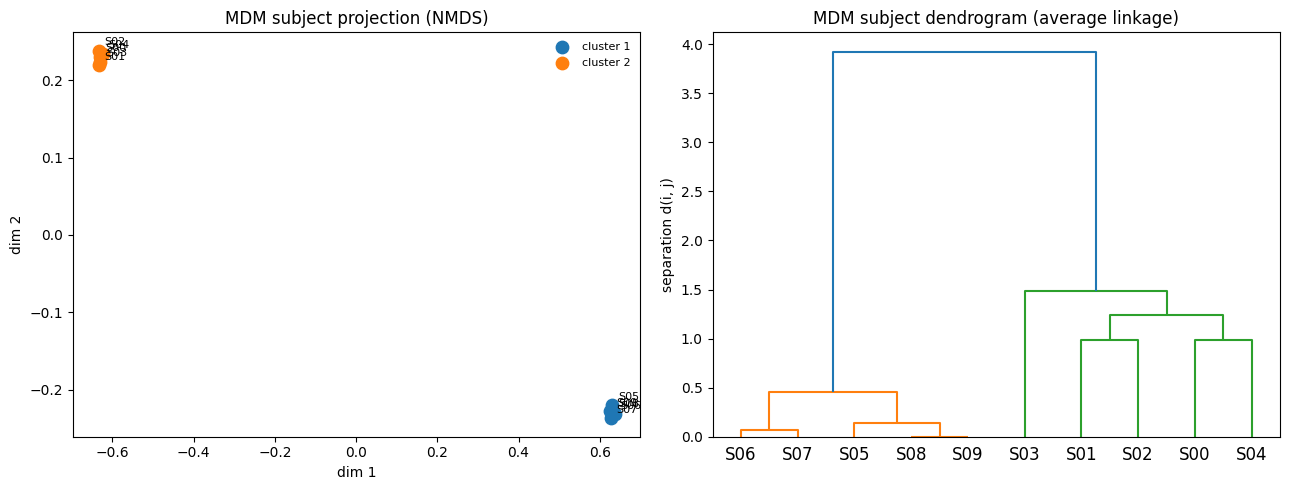

In [13]:
labels = suggest_clusters(dist)
print("Suggested clusters:", labels.tolist())
print("Nearest neighbours of S00:", nearest_neighbours(dist, "S00", k=2))

fig = plot_group_embedding(dist, technique="nmds", n_clusters=2)
plt.show()

Suggested clusters: [2, 2, 2, 2, 2, 1, 1, 1, 1, 1]
Nearest neighbours of S00: [('S04', 0.9862234511801944), ('S02', 1.1513301347603146)]


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


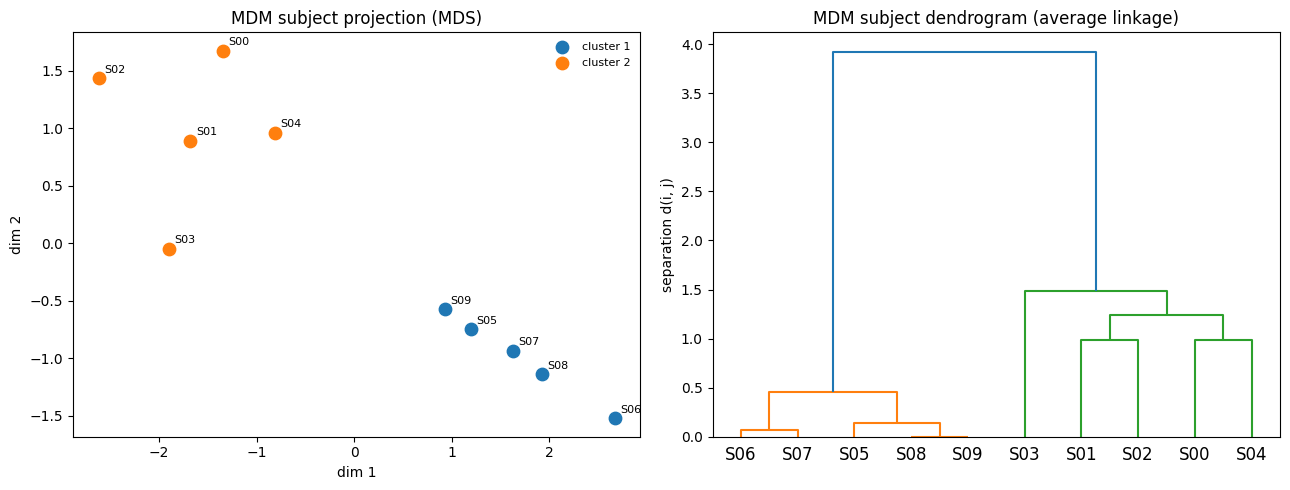

In [14]:
labels = suggest_clusters(dist)
print("Suggested clusters:", labels.tolist())
print("Nearest neighbours of S00:", nearest_neighbours(dist, "S00", k=2))

fig = plot_group_embedding(dist, technique="mds", n_clusters=2)
plt.show()

Suggested clusters: [2, 2, 2, 2, 2, 1, 1, 1, 1, 1]
Nearest neighbours of S00: [('S04', 0.9862234511801944), ('S02', 1.1513301347603146)]


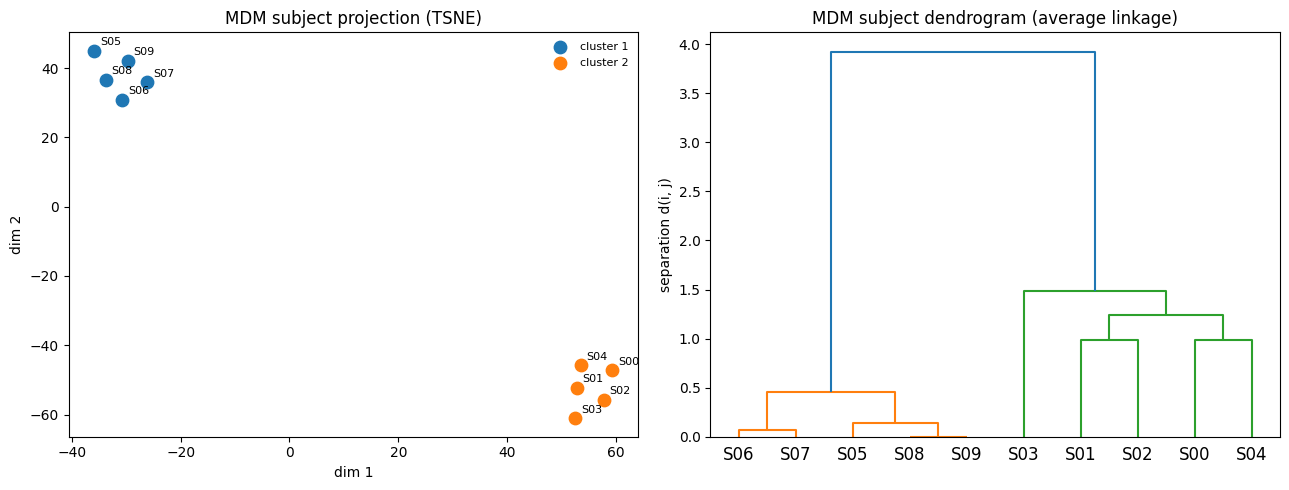

In [15]:
labels = suggest_clusters(dist)
print("Suggested clusters:", labels.tolist())
print("Nearest neighbours of S00:", nearest_neighbours(dist, "S00", k=2))

fig = plot_group_embedding(dist, technique="tsne", n_clusters=2)
plt.show()